**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Segundo Examen Parcial**

*18 de noviembre, 2025*




---


Nombre y Apellido:

---



Número de registro:

---



**Abajo de esta línea, importá/instalá todas las *libraries* que consideres relevantes para la resolución de este examen.**

In [58]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy_financial as nf

**Funciones útiles**

In [59]:
# Valor máximo de las ejes de coordenadas para mejor visualización
def x_y_max (value, factor, eje):
    value = int(float(value))
    return value*factor if (eje == 'x') else (value + factor)

In [60]:
# Fórmula de Equivalencia
def tasa_equivalente(i_t1, t2, t1):
    return (1 + i_t1) ** (t2 / t1) - 1

In [61]:
# Período de recuperación descontado
def payback_desc(flujos, rate):
    acum_desc = 0
    prd = None
    inversion_inicial = abs(flujos[0])
    
    for t in range(1, len(flujos)):
        # Descontar el flujo de caja actual
        discounted_flow = flujos[t] / (1 + rate)**t
        acum_desc += discounted_flow

        # Verificar si el flujo de caja descontado acumulado es mayor o igual a la inversión inicial
        if acum_desc >= inversion_inicial:
            # Si es así, calcular el período de recuperación descontado
            remaining_investment = inversion_inicial - (acum_desc - discounted_flow)
            prd = t - 1 + (remaining_investment / discounted_flow)
            break
    
    return prd

## Unidad 4

### Ejercicio 1

Supongamos que una empresa opera en un mercado y tiene las siguientes funciones:

- Función de Ingreso Marginal ($IMg$): $$ IMg(q) = 150 - 0.05 \cdot q $$

  donde $q$ es la cantidad producida.

- Función de Costo Marginal ($CMg$): $$ CMg(q) = 0.003 \cdot q^2 - 0.4 \cdot q + 80 $$

Además, se sabe que el costo fijo de la empresa es de $\$2000$.

**Integración I**

- Recuperar la función de Ingreso Total, $I(q)$, asumiendo que el ingreso total es cero cuando la cantidad producida es cero: $I(0) = 0$.

In [62]:
# Paso 1: Defino variables simbólicas
q = sp.symbols('q', positive=True)
q

q

In [63]:
# PAso 2: Defino la función de Ingreso Marginal IMg
IMg = 150.0 - 0.05*q
IMg

150.0 - 0.05*q

In [64]:
# Paso 3: Integro para obtener la función de Ingreso Total I(q)
I = sp.integrate(IMg, q)
I = sp.simplify(I)
I

q*(150.0 - 0.025*q)

In [65]:
sp.diff(I, q).simplify() == IMg

True

- Recuperar la función de Costo Total, $C(q)$.

In [66]:
# Paso 1: Defino variable simbólica F
F = sp.symbols('F')
F

F

In [67]:
# Paso 2: Defino la función de Costo Marginal CMg
CMg = 80.0 - 0.4*q + 0.003*q**2
CMg = sp.simplify(CMg)
CMg

0.003*q**2 - 0.4*q + 80.0

In [68]:
# Paso 3: Integro la función de CMg para obtener la función de Costo Total C(q)
C = sp.integrate(CMg, q) + F
C = sp.simplify(C)
C

F + 0.001*q**3 - 0.2*q**2 + 80.0*q

In [69]:
# Paso 4: Sustituyo el Costo Fijo en la función C(0) = F = 2000
C = C.subs(F, 2000)
C

0.001*q**3 - 0.2*q**2 + 80.0*q + 2000

- Calcular la función de Beneficio Total ($B(q)$)

In [70]:
# Beneficio
B = I - C
B = sp.simplify(B)
B

-0.001*q**3 + 0.175*q**2 + 70.0*q - 2000.0

- Encontrar la cantidad óptima ($q^{*}$). Esto es, determinar la cantidad de producción que maximiza el beneficio.

  Recordar: podemos lograr esto igualando el ingreso marginal al costo marginal, $IMg(q) = CMg(q)$, y resolviendo para $q$. Considerar solo valores de $q > 0$.

In [77]:
q_opt = round(sp.solve(sp.Eq(IMg, CMg), q)[0])
q_opt.evalf()

222.000000000000

- Calcular el Beneficio Máximo, $B^{*}(q)$.

In [79]:
B_opt = B.subs(q, q_opt)
round(B_opt, 2)

11223.65

- Visualizar las funciones de ingreso total, costo total y beneficio total en un mismo gráfico. Visualizar el punto de beneficio máximo. Interpretar el gráfico y sus componentes.

In [80]:
# Paso 1: Creo dominio de X, X_max y x_y_max
x_max = int(float(q_opt))
x_max = x_y_max(x_max, 1.75, 'x')

y_max = 55000

q_grid = np.linspace(0, x_max, 500)

In [81]:
# Paso 2: Convierto funciones simbólicas a numéricas
I_num = sp.lambdify(q, I)
C_num = sp.lambdify(q, C)
B_num = sp.lambdify(q, B)


In [82]:
# Paso 3: Evalúo las funciones numéricas en el dominio de x
I_vals = I_num(q_grid)
C_vals = C_num(q_grid)
B_vals = B_num(q_grid)

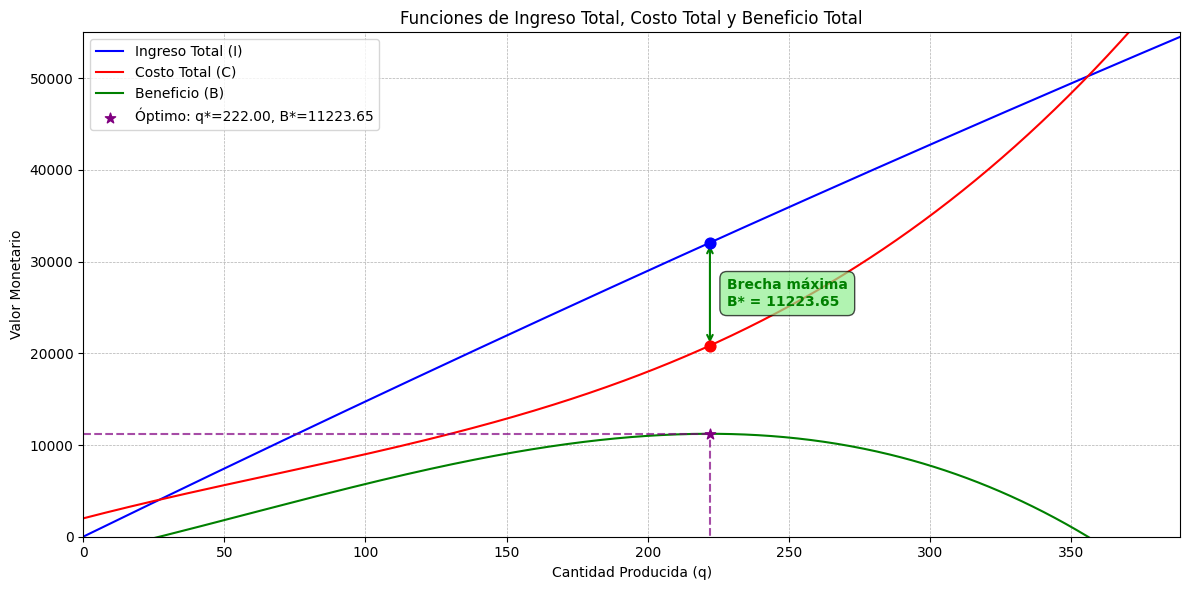

In [83]:
# Paso 4: Creo el gráfico
fig, axs = plt.subplots(figsize=(12, 6))

# Variables
I_opt = float(I_num(q_opt))
C_opt = float(C_num(q_opt))
B_opt = float(B_opt)
q_opt = float(q_opt)

# Grafico las funciones
axs.plot(q_grid, I_vals, label='Ingreso Total (I)', color='blue')
axs.plot(q_grid, C_vals, label='Costo Total (C)', color='red')
axs.plot(q_grid, B_vals, label='Beneficio (B)', color='green')

# Marco el punto óptimo
axs.scatter(q_opt, B_opt, color='purple', s=60, label=f'Óptimo: q*={q_opt:.2f}, B*={B_opt:.2f}', marker='*', zorder=5)
axs.scatter(q_opt, I_opt, color='blue', s=60, zorder=4, marker='o')
axs.scatter(q_opt, C_opt, color='red', s=60, zorder=4, marker='o')

# Líneas de referencias
axs.vlines(x=q_opt, ymin=axs.get_ylim()[0], ymax=B_opt, color='purple', linestyle='--', alpha=0.7)
axs.hlines(y=B_opt, xmin=axs.get_xlim()[0], xmax=q_opt, color='purple', linestyle='--', alpha=0.7)

# Flecha bidireccional mostrando la distancia máxima (beneficio)
axs.annotate('', 
            xy=(q_opt, I_opt), 
            xytext=(q_opt, C_opt),
            arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))

# Etiqueta explicativa de la brecha
axs.text(q_opt + 6, (I_opt + C_opt) / 2.1, 
        f'Brecha máxima\nB* = {B_opt:.2f}', 
        fontsize=10, color='green', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7))

# Configuro Gráfico
axs.grid(True, which='both', linestyle='--', linewidth=0.5)
axs.set_title('Funciones de Ingreso Total, Costo Total y Beneficio Total')
axs.set_xlabel('Cantidad Producida (q)')
axs.set_ylabel('Valor Monetario')
axs.set_xlim(0, x_max)
axs.set_ylim(0, y_max)
axs.legend()

plt.tight_layout()
plt.show()

### Ejercicio 2

Las funciones de oferta y demanda de cierto producto están dadas por:

$$O: p=45+2q$$

$$D:p= 144-q^2$$

**Integración II**

- Determinar el Excedente del Consumidor (EC) y el Excedente del Productor (EP).

- Graficar ambas funciones en un mismo gráfico, donde el eje vertical (ordenadas) debe ser el precio y el horizontal (abscisas) la cantidad.

- Sombrear las áreas correspondientes a los excedentes encontrados indicando en el gráfico cuál es el excedente del consumidor y cuál el del productor. Interpretar.

### Ejercicio 3

Dada la función de Costo marginal

$$CMg=0.01-\dfrac{500}{x^{2}}$$

**Integración III**

- Hallar la función de Costo total.

- Calcular el costo total de producir 100 unidades si el costo fijo asciende a $F = 50$.

- Calcular, a través de una integral definida, el costo total variable acumulado entre 30 y 45 unidades.

- Graficar costo total y costo marginal. Interpretar el gráfico.

## Unidad 5

### Ejercicio 4

A partir del cash flow MENSUAL establecido en la línea de código propuesta a continuación y considerando un costo de capital anual del 11%, realice un análisis que contenga:

- Métricas financieras: VAN, TIR, TIRM y Payback Descontado (*Período de Recuperación Descontado, PRD*) e interprete cada una de ellas.

In [ ]:
inversion_inicial = -50000
cash_flows = [
    10000, -12000, 15000, 18000, 20000, 22000, 25000, 28000, -30000, 32000,
    -5000, 10000, 13000, 16000, -19000, 21000, -24000, 27000, -23000, 33000,
    -8000, 11000, -14000, 17000, 20000, 23000, 26000, -25000, 32000
]
nuevo_cash_flow = [inversion_inicial] + cash_flows

- Grafique el flujo de fondos.

- Grafique el VAN a diferentes tasas de descuento de costo de capital. Marque en dicho gráfico la TIR. Explique el gráfico y sus componentes.

- Considere que el gerente financiero pronostica un aumento posible del costo de capital a la hora de iniciar el proyecto conformando un costo total del 17% anual. Realice el análisis nuevamente e interprete los resultados.

- Haga un gráfico comparativo de ambas situaciones.

### Ejercicio 5

Importe el dataset `Cripto_metrics.csv` y realice:
- exploración inicial del mismo.

- Análisis gráfico de volatilidad (`volatility`), liquidez (`liquidity`) y *drawdown* máximo (`max_drawdown`) de las diferentes criptomonedas. Saque conclusiones.

  **Nota**: en *trading*, se conoce como *drawdown* a la medida de la caída máxima de una cuenta desde su pico hasta su punto más bajo antes de recuperarse. Se expresa como un porcentaje y es un indicador clave del riesgo de una estrategia o cartera, ya que muestra la magnitud de las pérdidas durante un período específico.

- Compare `Tether` y `USDC` versus `Solana` y `Cardano`. Saque conclusiones.